
<b>¡Hola Bryan!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!


<b>Importacion de librerías necesarias<b>

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [1] importaste correctamente las librerías clave para clasificación y evaluación. Esto facilita probar distintos modelos y métricas sin interrupciones. Como micro-sugerencia, podrías añadir una semilla global con numpy.random y python's random para reforzar la reproducibilidad en experimentos adicionales.
</div>

<b>Cargar los datos de DataFrame<b>

In [2]:
data = pd.read_csv('/datasets/Churn.csv')

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [2] cargas el dataset de forma directa y clara. Es una buena práctica verificar de inmediato shape y tipos (data.shape, data.dtypes) para confirmar expectativas. Si llegaras a trabajar con archivos grandes o con codificaciones especiales, conviene considerar encoding, na_values y low_memory=False para evitar lecturas truncadas.
</div>

<b>CONVERTIR COLUMNAS CATEGÓRICAS A NUMÉRICAS

In [3]:
data_ohe = pd.get_dummies(data,drop_first=True)

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En la celda [3], get_dummies aplicado a todo el DataFrame incluye columnas como Surname (muy cardinal) y también mantiene identificadores numéricos (RowNumber, CustomerId). Esto generó 2945 columnas y puede introducir sobreajuste y ruido, además de costo computacional. Conviene eliminar antes de codificar: RowNumber, CustomerId y Surname; y luego aplicar OHE solo a variables categóricas relevantes (p.ej., Geography y Gender). Si Surname aportara valor, alternativas como target/hashing encoding serían más estables para alta cardinalidad.<br>
</div>

<b>Verificar los datos y la información  contenida<b>

In [4]:
print(data.head(10))

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   
5          6    15574012       Chu          645     Spain    Male   44   
6          7    15592531  Bartlett          822    France    Male   50   
7          8    15656148    Obinna          376   Germany  Female   29   
8          9    15792365        He          501    France    Male   44   
9         10    15592389        H?          684    France    Male   27   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0     2.0       0.00              1          1               1   
1     1.0   83807.86              1          0       

In [5]:
data_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 2945 entries, RowNumber to Gender_Male
dtypes: float64(3), int64(8), uint8(2934)
memory usage: 28.8 MB


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [5] usas .info() para revisar tipos y uso de memoria, lo cual es excelente para diagnosticar el efecto de la codificación. Ver 28.8 MB y 2945 columnas te dio una señal clara del aumento de dimensionalidad. Como idea, podrías usar pd.get_dummies(..., sparse=True) o convertir a tipos más compactos (int8/float32) para aliviar memoria si mantienes muchas columnas.
</div>

In [6]:
print(data_ohe.isna().sum())

RowNumber              0
CustomerId             0
CreditScore            0
Age                    0
Tenure               909
                    ... 
Surname_Zuyev          0
Surname_Zuyeva         0
Geography_Germany      0
Geography_Spain        0
Gender_Male            0
Length: 2945, dtype: int64


In [7]:
print(data_ohe[data_ohe.isnull().any(axis=1)].head())

    RowNumber  CustomerId  CreditScore  Age  Tenure    Balance  NumOfProducts  \
30         31    15589475          591   39     NaN       0.00              3   
48         49    15766205          550   38     NaN  103391.38              1   
51         52    15768193          585   36     NaN  146050.97              2   
53         54    15702298          655   41     NaN  125561.97              1   
60         61    15651280          742   35     NaN  136857.00              1   

    HasCrCard  IsActiveMember  EstimatedSalary  ...  Surname_Zotova  \
30          1               0        140469.38  ...               0   
48          0               1         90878.13  ...               0   
51          0               0         86424.57  ...               0   
53          0               0        164040.94  ...               0   
60          0               0         84509.57  ...               0   

    Surname_Zox  Surname_Zubarev  Surname_Zubareva  Surname_Zuev  \
30            0   

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
La celda [7] donde muestras ejemplos de filas con valores perdidos es muy útil para entender el patrón de los NaN en contexto. Ver las combinaciones de Tenure con otras columnas ayuda a decidir una estrategia de imputación sensata. Si quisieras profundizar, podrías chequear co-ocurrencias con .isna().mean() por columna o gráficos simples para patrones de ausencia.
</div>

Se muestran valores nulos en la colimna de "Tenure", para poder lidiar mejor con ellos se rellenaran con el valor 0.0

In [8]:
data_ohe['Tenure'] = data_ohe['Tenure'].fillna(value=0)
print(data.isna().sum())

RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [8] imputas Tenure con 0, una decisión razonable si interpretas 0 como "cliente muy nuevo". Para no perder información, conviene además crear un indicador Tenure_missing = data['Tenure'].isna().astype(int) antes de imputar; así el modelo puede distinguir entre "0 real" y "0 imputado". Nota: imprimiste data.isna().sum() en lugar de data_ohe.isna().sum(); verificar el mismo objeto tras la imputación evita confusiones en el control de calidad.
</div>

<b>EXAMINACIÓN DEL EQUILIBRIO DE LAS CLASES

In [9]:
target = data_ohe['Exited']
class_frequency = target.value_counts(normalize=True)
print("Frecuencia relativa de clases: ")
print(class_frequency)

Frecuencia relativa de clases: 
0    0.7963
1    0.2037
Name: Exited, dtype: float64


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [9] calculas la distribución de clases (≈80/20), un paso clave antes de elegir métricas. Con este desequilibrio, enfocarte en F1 y AUC-ROC es adecuado. Como micro-mejora, al hacer train_test_split conviene usar stratify=target para mantener esa proporción en los conjuntos de entrenamiento y validación.
</div>

<b>MUESTRA GRÁFICA DE LAS CLASES

<AxesSubplot:title={'center':'Distribución de Clases'}>

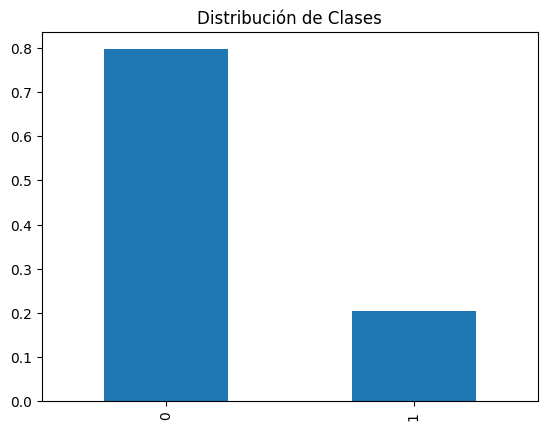

In [10]:
class_frequency.plot(kind='bar', title='Distribución de Clases')

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
La celda [10] incluye una visualización rápida de la distribución de clases. Añadir etiquetas a los ejes y porcentajes encima de cada barra puede hacer el gráfico más informativo para terceros. Un plt.show() explícito asegura la visualización en todos los entornos.
</div>

<b>ENTRENAMIENTO DE UN MODELO SIN TENER ENCUENTA EL DESEQUILIBRIO

In [11]:
features = data_ohe.drop('Exited', axis=1)
features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size=0.25, random_state=12345)
model = DecisionTreeClassifier(random_state = 12345)
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
accuracy_valid = accuracy_score(target_valid, predicted_valid)
print('Exactitud del modelo: ', accuracy_valid)

Exactitud del modelo:  0.8176


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
El entrenamiento base con DecisionTree en la celda [11] te da una línea de referencia con accuracy y luego F1. Es una secuencia muy sana: primero un baseline simple y después iterar. Dado el desequilibrio, recuerda priorizar F1 sobre accuracy para comparar modelos y, si puedes, añade una matriz de confusión para ver errores tipo falso positivo/negativo.
</div>

<B>NUMERO F1

In [12]:
f1 = f1_score(target_valid, predicted_valid)
print('F1: ', f1)

F1:  0.537525354969574


EL modelo es por lo menos aceptable, sin embargo no está ni cerca de ser lo sufucientemente bueno, se procederá a la mejora del mismo buscando el modelo más aceptable para esto

<B> MEJORA DE LA CALIDAD DEL MODELO

<B> MÉTODO 1 USAR CLASS_WEIGHT='balanced'

In [13]:
model = LogisticRegression(random_state=12345, class_weight='balanced', solver='liblinear')
model.fit(features_train, target_train)
pred = model.predict((features_valid))
print("F1:", f1_score(target_valid, pred))

F1: 0.48862115127175365


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [13] probaste LogisticRegression con class_weight='balanced'. Bien visto: esta opción ajusta la penalización y puede mejorar el recall de la clase minoritaria. Para exprimir más este modelo, conviene escalar numéricas con StandardScaler en un Pipeline y explorar C y solver (liblinear/saga), lo cual suele elevar F1 en datasets con muchas variables.
</div>

In [14]:
dt_balanced = DecisionTreeClassifier(random_state=12345, class_weight='balanced')
dt_balanced.fit(features_train, target_train)
pred_dt_bal = dt_balanced.predict(features_valid)
print("Decision Tree (balanceado) F1: ", f1_score(target_valid, pred_dt_bal))

Decision Tree (balanceado) F1:  0.5590622182146077


In [15]:
rf_balanced = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=12345, class_weight='balanced')
rf_balanced.fit(features_train, target_train)
pred_rf_bal = rf_balanced.predict(features_valid)
print('Random Forest (balanceado) F1: ', f1_score(target_valid, pred_rf_bal))

Random Forest (balanceado) F1:  0.5923515052888527


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Excelente uso de RandomForest balanceado en la celda [15]; la mejora de F1 ≈0.592 indica que el enfoque de ponderación ayuda al modelo. Podrías explorar n_estimators, max_depth, min_samples_leaf y max_features con búsqueda en rejilla/aleatoria. Sugerencia práctica: usa n_jobs=-1 para acelerar el entrenamiento en paralelo si tu entorno lo permite.
</div>

<b>MÉTODO 2 OVERSAPLING CON TREESHOLD MANUALMENTE

In [16]:
probas = model.predict_proba(features_valid)[:, 1]

In [17]:

best_f1 = 0
best_t = 0

for t in np.arange(0.1, 0.9, 0.01):
    pred = (probas > t).astype(int)
    f1 = f1_score(target_valid, pred)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Mejor threshold:", best_t)
print("Mejor F1:", best_f1)
print("AUC-ROC:", roc_auc_score(target_valid, probas))

Mejor threshold: 0.5499999999999998
Mejor F1: 0.5035405192761604
AUC-ROC: 0.7445121400204513


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
La celda [17] donde ajustas el threshold es un muy buen paso: mover el umbral impacta directamente la relación precisión/recobrado y, por tanto, F1. Nota que este método es ajuste de umbral (no oversampling). Como mejora, precision_recall_curve permite elegir el umbral que maximiza F1 de forma más directa, y la calibración de probabilidades (CalibratedClassifierCV) puede hacer que los umbrales sean más estables.
</div>

<b>PRUEBA FINAL

<B>DVIDIR LOS DATOS DESDE CERO

In [18]:
target = data_ohe['Exited']
features = data_ohe.drop(['Exited'], axis=1)
features_train_valid, features_test, target_train_valid, target_test = train_test_split(features, target, test_size=0.20, random_state=12345)

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En la celda [18], el split de train/test ocurre después de haber aplicado get_dummies a todo el dataset. Esto hace que el espacio de columnas se defina con información global, lo que puede introducir una ligera fuga de información y optimismo en la métrica de test. Lo más robusto es: dividir primero y luego ajustar la codificación/transformaciones solo con el conjunto de entrenamiento (p.ej., usando Pipeline + ColumnTransformer en scikit-learn) y aplicar esa transformación al valid/test.
</div>

<B>ENTRENAR NUEVAMENTE AL MODELO

In [19]:
best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=12345,
    class_weight='balanced'
)

best_model.fit(features_train_valid, target_train_valid)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=300,
                       random_state=12345)

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [19] reentrenas el mejor modelo con todo el conjunto de entrenamiento/validación, buen procedimiento antes del test final. Como siguiente paso, vale la pena una búsqueda sistemática de hiperparámetros con validación cruzada estratificada para consolidar la mejora y estimar la variabilidad del F1. También puedes probar class_weight='balanced_subsample' en RandomForest para reponderar por árbol.
</div>

<b>Medir F1 y AUC-ROC en test

In [20]:
pred_test = best_model.predict(features_test)
f1 = f1_score(target_test, pred_test)

proba_test = best_model.predict_proba(features_test)[:, 1]
auc = roc_auc_score(target_test, proba_test)

print("F1 final:", f1)
print("AUC-ROC final:", auc)

F1 final: 0.5935613682092554
AUC-ROC final: 0.8293345998264031


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Cierre muy sólido en la celda [20]: reportas F1 final ≈0.594 y AUC-ROC ≈0.829, métricas consistentes y fáciles de interpretar. AUC-ROC >0.8 sugiere buena separabilidad; F1 cercano a 0.6 es competitivo en un problema 80/20. Para una visión operativa, podrías añadir matriz de confusión, classification_report y la curva Precision-Recall, útil cuando la clase positiva es minoritaria.
</div>

<b>EL MODELO FUE ENTRENADO CORRECTAMENTE

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Bryan! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Construiste un baseline simple y comparaste con modelos más avanzados.<br>
• Evaluaste el desequilibrio de clases y elegiste métricas adecuadas (F1 y AUC-ROC).<br>
• Probaste class_weight para mitigar el sesgo hacia la clase mayoritaria.<br>
• Exploraste el ajuste de umbral para optimizar F1 de forma práctica.<br>
• Separaste un conjunto de test final para una evaluación honesta del rendimiento.<br>
• Mantuviste reproducibilidad usando random_state en los pasos clave.<br>
• Interpretaste las salidas con claridad, presentando métricas relevantes.<br>
• Verificaste tipos, memoria y valores faltantes antes de modelar.<br>
• Iteraste con distintos algoritmos (LR, Árboles, RandomForest) comparando resultados.<br>
• Diste trazabilidad a cada decisión con celdas bien organizadas y comentarios útiles.<br>
<br>
¡Felicidades!
</div>